## 1. Load the Dataset

This notebook begins by importing the e-commerce dataset and verifying that the data has been loaded correctly.

In [2]:
# !python3 -m pip install kagglehub

In [3]:

import kagglehub
# Download latest version
path = kagglehub.dataset_download("abbas829/ecommerce-sales-dataset")
print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/dottie/.cache/kagglehub/datasets/abbas829/ecommerce-sales-dataset/versions/1


In [4]:
# !python3 -m pip install pandas
import pandas as pd
df = pd.read_csv("raw_data/ecommerce_sales_analytics_5000.csv")

# understand the dataset
print ("Data loaded successfully!")
print("The first 5 rows of the dataset are:")
print(df.head())
print("The shape of the dataset is:", df.shape)


Data loaded successfully!
The first 5 rows of the dataset are:
   order_id order_date  customer_id product_category region  quantity  \
0     10001   1/1/2022         1102           Beauty  South         7   
1     10002   1/2/2022         1435         Clothing  South         7   
2     10003   1/3/2022         1860           Beauty   East         3   
3     10004   1/4/2022         1270      Electronics   West         5   
4     10005   1/5/2022         1106         Clothing   West         5   

   unit_price  discount payment_method  delivery_days  customer_rating  \
0      373.65      0.28         Wallet             10              4.7   
1       47.74      0.09           Card              6              3.9   
2      311.28      0.31            COD              6              2.5   
3      524.47      0.02         Wallet              6              1.6   
4      139.87      0.33         Wallet              4              4.9   

   revenue  
0  1883.20  
1   304.10  
2   644.35  
3

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


In [6]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


## 2. Data Quality Assessment

This section evaluates the dataset for missing values, duplicate records, spelling inconsistencies, data type issues, and outliers to ensure analysis quality and reliability.

In [7]:
# check if there is missing value in the dataset

df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

The dataset is complete, with no missing values detected.

In [8]:
# check if there is duplicated row in the dataset 
df.duplicated().sum()

np.int64(0)

There are no duplicate rows across the 5,000 records in the dataset.

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])
print("The data type of 'order_date' column after conversion is:", df['order_date'].dtype)

The data type of 'order_date' column after conversion is: datetime64[us]


In [10]:
print(df['order_date'])

0      2022-01-01
1      2022-01-02
2      2022-01-03
3      2022-01-04
4      2022-01-05
          ...    
4995   2035-09-05
4996   2035-09-06
4997   2035-09-07
4998   2035-09-08
4999   2035-09-09
Name: order_date, Length: 5000, dtype: datetime64[us]


In [11]:
# check unique values in categorical columns, in case there is spelling error 
print("Unique product categories in the dataset are:")
df['product_category'].unique()


Unique product categories in the dataset are:


<StringArray>
['Beauty', 'Clothing', 'Electronics', 'Home']
Length: 4, dtype: str

In [12]:
print("Unique regions in the dataset are:")
df['region'].unique()

Unique regions in the dataset are:


<StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

In [13]:
print("Unique payment methods in the dataset are:")
df['payment_method'].unique()

Unique payment methods in the dataset are:


<StringArray>
['Wallet', 'Card', 'COD']
Length: 3, dtype: str

## 3. Exploratory Data Analysis

This section summarizes the main patterns in the dataset and provides a business-oriented interpretation of key metrics and distributions.

### 3.1 Overall Business Performance

This subsection provides a high-level summary of the dataset, including revenue, order volume, customer base size, and product demand.

In [14]:
total_revenue = df['revenue'].sum()
print("Total revenue generated from the dataset is:", total_revenue)

total_orders = df['order_id'].nunique()
print("Total number of unique orders in the dataset is:", total_orders)

total_customers = df['customer_id'].nunique()
print("Total number of unique customers in the dataset is:", total_customers)

total_units = df['quantity'].sum()
print("Total number of units sold in the dataset is:", total_units)

average_order_value = total_revenue / total_orders
print("Average order value (AOV) is:", average_order_value)

average_units_per_order = total_units / total_orders
print("Average units sold per order is:", average_units_per_order)

average_unit_price = total_revenue / total_units
print("Average unit price is:", average_unit_price)

average_discount = df['discount'].mean()
print("Average discount offered is:", average_discount)

average_rating = df['customer_rating'].mean()
print("Average customer rating is:", average_rating)

average_delivery_time = df['delivery_days'].mean()
print("Average delivery time in days is:", average_delivery_time)

average_lifetime_value = df.groupby('customer_id')['revenue'].sum().mean()
print("Average customer lifetime value (CLV) is:", average_lifetime_value)

Total revenue generated from the dataset is: 5109775.74
Total number of unique orders in the dataset is: 5000
Total number of unique customers in the dataset is: 989
Total number of units sold in the dataset is: 20224
Average order value (AOV) is: 1021.955148
Average units sold per order is: 4.0448
Average unit price is: 252.65900613132914
Average discount offered is: 0.179984
Average customer rating is: 2.9739800000000005
Average delivery time in days is: 6.1188
Average customer lifetime value (CLV) is: 5166.608432760364


Each order is unique, while customers appear multiple times across the dataset. The average customer rating is 2.97, which is relatively low and will be examined in more detail later. The average customer lifetime value (CLV) is €5,166.61.

### 3.2 Univariate Analysis

This subsection examines the distribution of individual variables and highlights notable patterns in customer behavior, order trends, and product mix.

#### 3.2.1 Customer ID

This analysis looks at the number of orders placed by each customer to understand repeat-purchase behavior and customer frequency.

In [15]:
orders_per_customer = (
   df.groupby('customer_id')['order_id'].nunique() 
)
print(orders_per_customer)
orders_per_customer.describe()

customer_id
1000    9
1001    6
1002    4
1003    2
1004    5
       ..
1995    4
1996    7
1997    6
1998    5
1999    1
Name: order_id, Length: 989, dtype: int64


count    989.000000
mean       5.055612
std        2.325258
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       14.000000
Name: order_id, dtype: float64

There are 989 unique customers, and the average customer places approximately 5 orders.

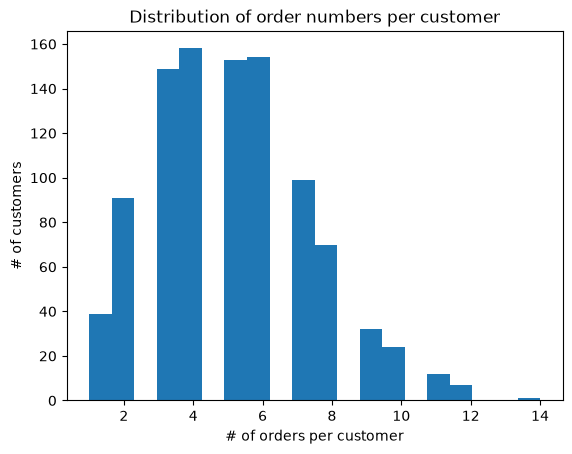

In [16]:
# !python3 -m pip install matplotlib
import matplotlib.pyplot as plt 
orders_per_customer.hist(bins=20, grid=False)
plt.xlabel('# of orders per customer')
plt.ylabel('# of customers')
plt.title('Distribution of order numbers per customer')

plt.show()

The distribution indicates that most customers place between 3 and 7 orders, with the highest concentration in the 4–6 order range. The number of customers declines as order frequency increases beyond 7 orders, and only a small share of customers place more than 10 orders.

Overall, the distribution is slightly right-skewed, suggesting that most customers exhibit moderate purchasing frequency.

#### 3.2.2 Order Date

This section reviews the time coverage of the dataset and identifies temporal patterns in order activity.

In [17]:
print('The dataset covers the following time period:', df['order_date'].min(), 'to', df['order_date'].max())

The dataset covers the following time period: 2022-01-01 00:00:00 to 2035-09-09 00:00:00


<Axes: title={'center': 'Number of Orders Over Time'}, xlabel='order_date'>

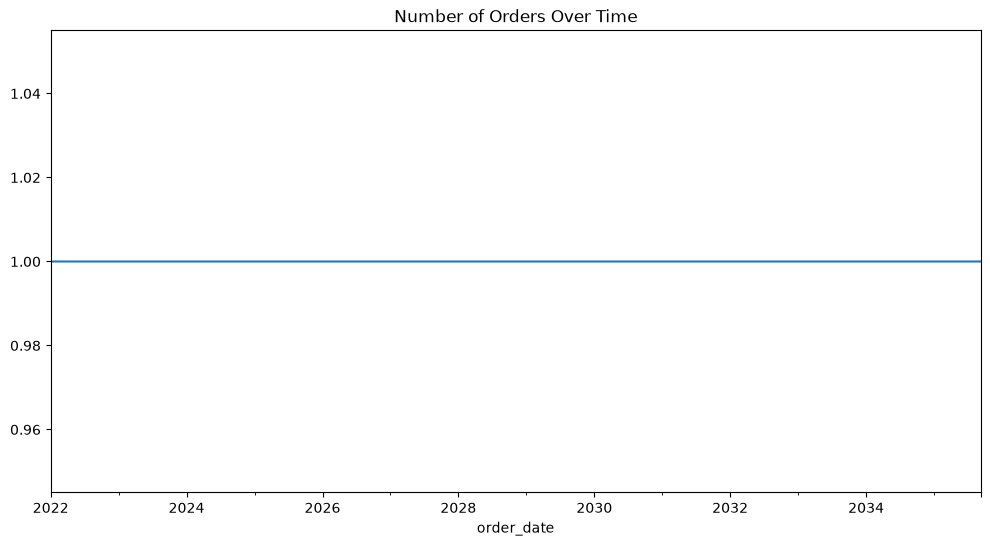

In [18]:
orders_by_date = df.groupby('order_date')['customer_id'].nunique()
orders_by_date.plot(figsize=(12,6), title='Number of Orders Over Time')

The dataset is synthetic, and the plot indicates that each date contains only a single order, which produces a near-linear trend over time.

In [19]:
# extract time components for later time series analysis
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.day_name()

In [20]:
print(df['year'].unique())

[2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035]


#### 3.2.3 Product Category

This section summarizes the distribution of orders across product categories and highlights category dominance within the customer base.

In [21]:
print('Number of unique product categories:', df['product_category'].nunique())
print('Value counts for each product category:')
df['product_category'].value_counts()

Number of unique product categories: 4
Value counts for each product category:


product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64

In [22]:
df['product_category'].value_counts(normalize=True) * 100

product_category
Electronics    35.54
Clothing       30.62
Home           19.38
Beauty         14.46
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribution of Product Categories'}, xlabel='Product Category', ylabel='Count'>

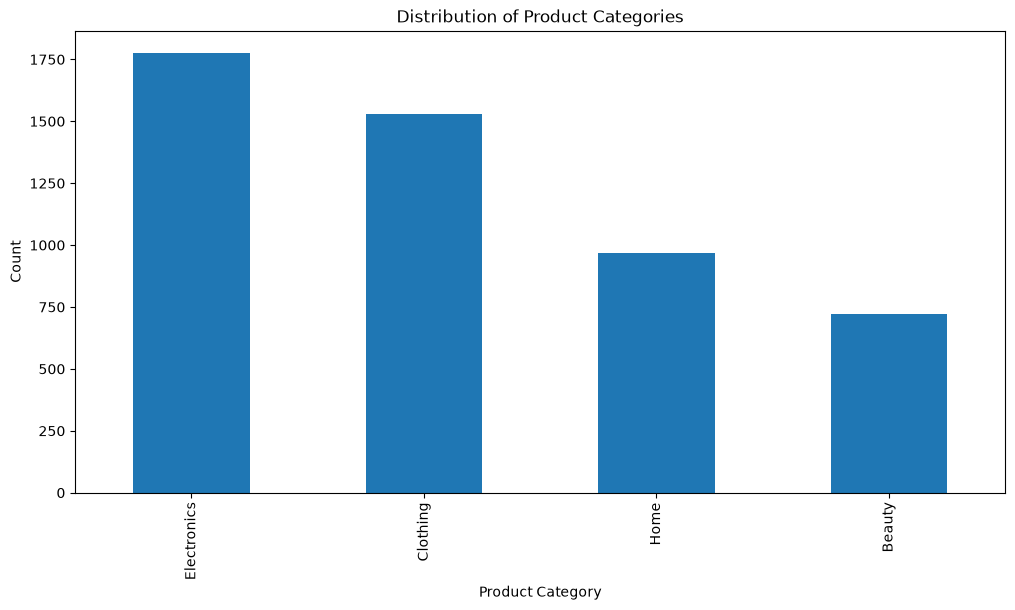

In [23]:
df['product_category'].value_counts().plot(kind='bar', figsize=(12,6), title='Distribution of Product Categories', xlabel='Product Category', ylabel='Count')

Electronics accounts for the largest share of transactions, while Beauty represents a smaller proportion of total orders.

#### 3.2.4 Region

This section examines the geographic distribution of orders and the relative share of activity across regions.

In [24]:
print('Number of unique regions is: ', df['region'].nunique())
print('Value counts for each product category:')
df['region'].value_counts()
df['region'].value_counts(normalize=True) * 100

Number of unique regions is:  4
Value counts for each product category:


region
West     25.78
North    25.52
East     24.54
South    24.16
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribution of Regions'}, xlabel='Region', ylabel='Count'>

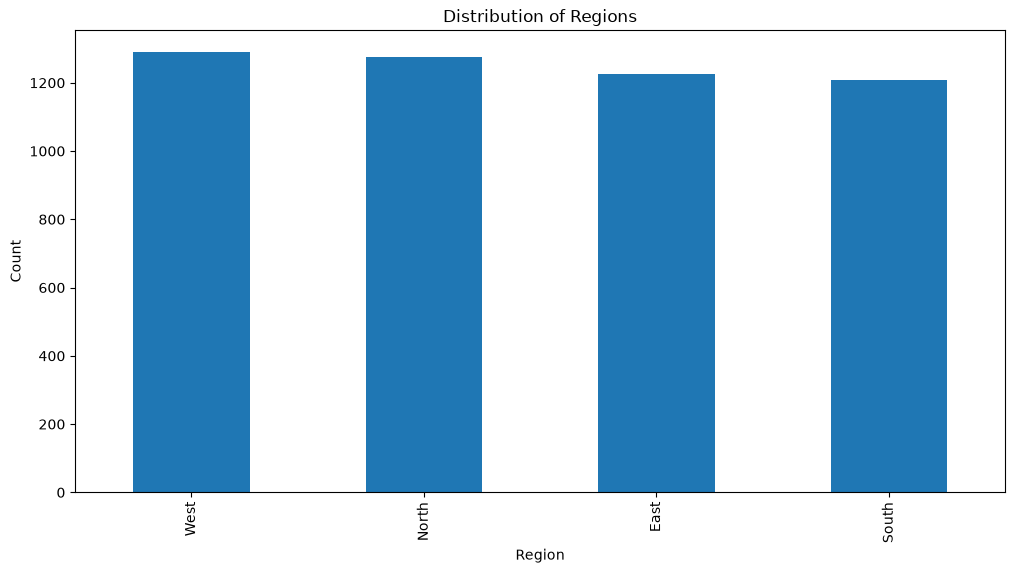

In [25]:
df['region'].value_counts().plot(kind='bar', figsize=(12,6), title='Distribution of Regions', xlabel='Region', ylabel='Count')

The dataset includes four regions, with the West region accounting for 25.78% of all orders.

#### 3.2.5 Payment Method

This section reviews customer payment preferences and compares the share of transactions by payment method.

In [26]:
print('Value counts for each payment method:')
df['payment_method'].value_counts()


Value counts for each payment method:


payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

In [27]:
df['payment_method'].value_counts(normalize=True) * 100

payment_method
Card      45.40
COD       35.48
Wallet    19.12
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribution of Payment Methods'}, xlabel='Payment Method', ylabel='Count'>

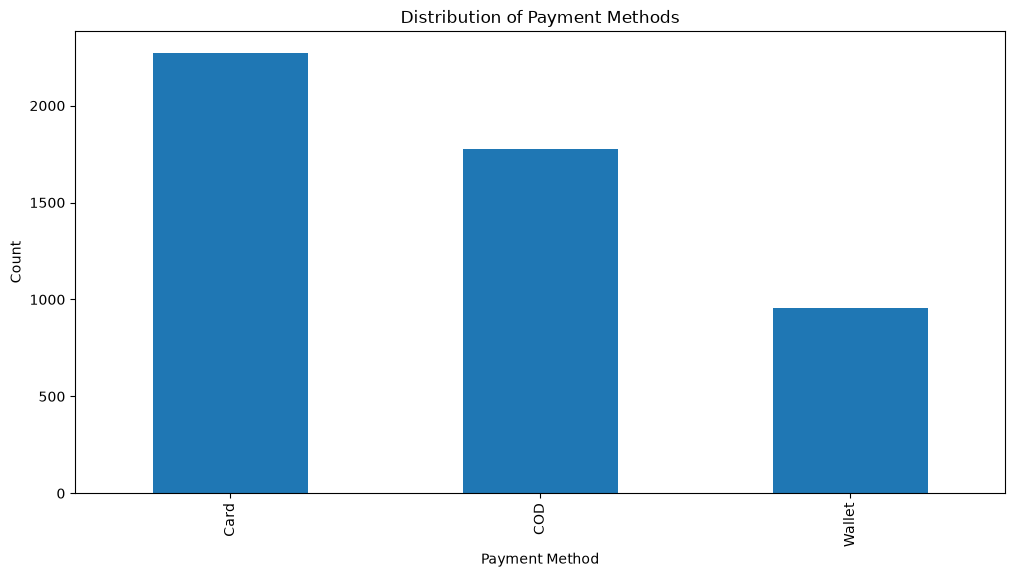

In [28]:
df['payment_method'].value_counts().plot(kind='bar', figsize=(12,6), title='Distribution of Payment Methods', xlabel='Payment Method', ylabel='Count')

Card payments are the most commonly used method, accounting for 45.4% of orders, while wallet payments are used in 19.12% of transactions.

#### 3.2.6 Quantity

This section analyzes the typical order size and the distribution of quantities purchased per transaction.

In [29]:
df['quantity'].value_counts()

quantity
7    775
2    721
4    718
6    713
1    704
5    698
3    671
Name: count, dtype: int64

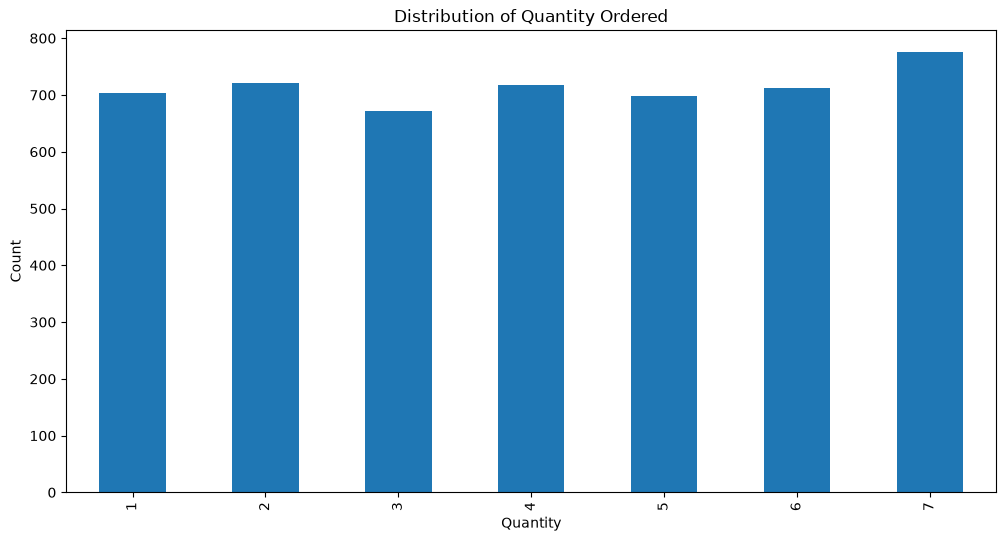

In [30]:
df['quantity'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.title('Distribution of Quantity Ordered')
plt.show()

In [31]:
df['quantity'].describe()

count    5000.000000
mean        4.044800
std         2.020398
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         7.000000
Name: quantity, dtype: float64

On average, each order contains 4 units. The highest volume occurs at 7 units per order, and the distribution is relatively balanced without strong skew toward very low or very high order quantities.

#### 3.2.7 Unit Price

This section examines the distribution of unit prices and identifies the range and spread of product pricing across the dataset.

In [32]:
df['unit_price'].describe()

count    5000.000000
mean      308.418774
std       169.259369
min        15.150000
25%       161.895000
50%       309.890000
75%       455.557500
max       599.960000
Name: unit_price, dtype: float64

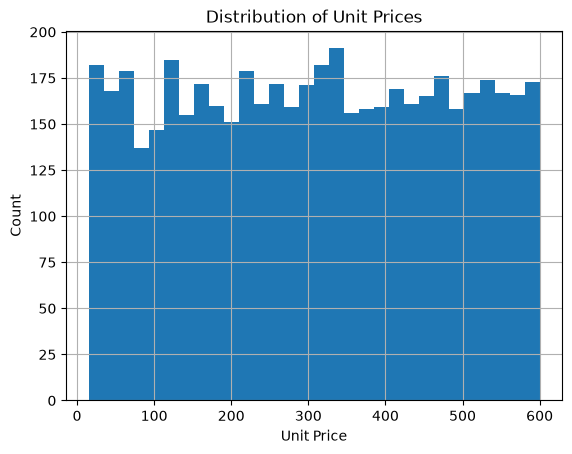

In [33]:
df['unit_price'].hist(bins=30)
plt.xlabel('Unit Price')
plt.ylabel('Count')
plt.title('Distribution of Unit Prices')
plt.show()

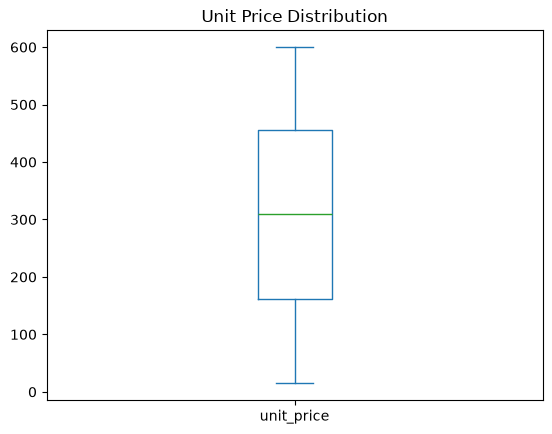

In [34]:
df['unit_price'].plot(kind='box')
plt.title('Unit Price Distribution')
plt.show()

df['unit_price]

In [35]:
df['unit_price'].skew()



np.float64(-0.010756503172726604)

The skewness is close to 0, implicating that the distrubution of unit price of products is approximately symmetric.

In [36]:
(df['unit_price'] <= 0).sum()

np.int64(0)

Since unit price is positive, this step is to check if there are any abnormal data. Negative values might indicate data erors, refunds, free products, or special transactions. But none of negative figures exist in this dataset.

3.2.8 discount

In [37]:
df['discount'].describe()

count    5000.000000
mean        0.179984
std         0.101404
min         0.000000
25%         0.090000
50%         0.180000
75%         0.270000
max         0.350000
Name: discount, dtype: float64

<Axes: >

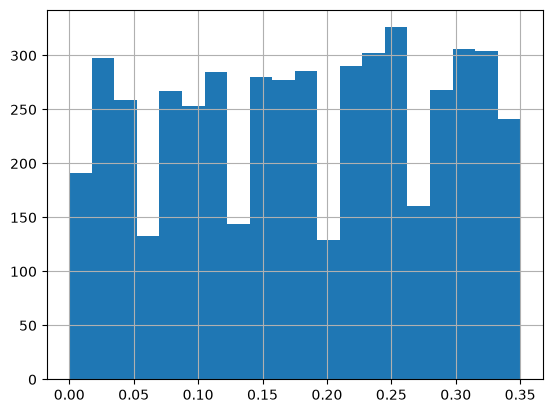

In [39]:
df['discount'].hist(bins=20)

3.2.9 delivery_days

In [41]:
df['delivery_days'].describe()

count    5000.000000
mean        6.118800
std         3.153264
min         1.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        11.000000
Name: delivery_days, dtype: float64

<Axes: >

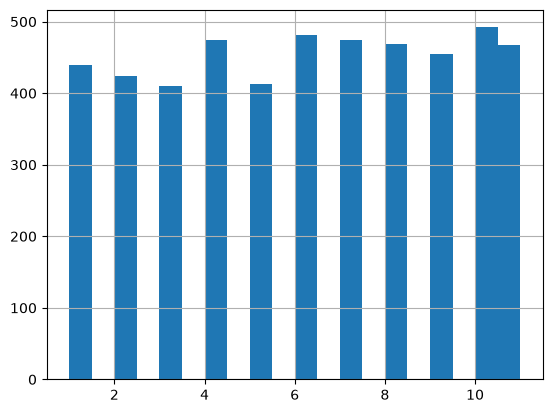

In [42]:
df['delivery_days'].hist(bins=20)

In [43]:
df['delivery_days'].value_counts().sort_index()

delivery_days
1     440
2     424
3     410
4     474
5     413
6     481
7     475
8     469
9     455
10    492
11    467
Name: count, dtype: int64

3.2.10 customer_rating

In [44]:
df['customer_rating'].describe()

count    5000.000000
mean        2.973980
std         1.157722
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: customer_rating, dtype: float64

In [47]:
df['customer_rating'].value_counts().sort_index()

customer_rating
1.0     80
1.1    121
1.2    119
1.3    125
1.4    134
1.5    129
1.6    122
1.7    143
1.8    127
1.9    115
2.0    129
2.1    116
2.2    149
2.3    137
2.4    133
2.5    119
2.6    127
2.7    119
2.8    112
2.9    121
3.0    128
3.1    137
3.2    139
3.3    107
3.4    116
3.5    137
3.6    133
3.7    111
3.8    121
3.9    125
4.0    105
4.1    133
4.2    116
4.3    122
4.4    126
4.5    108
4.6    124
4.7    118
4.8    126
4.9    118
5.0     73
Name: count, dtype: int64

<Axes: >

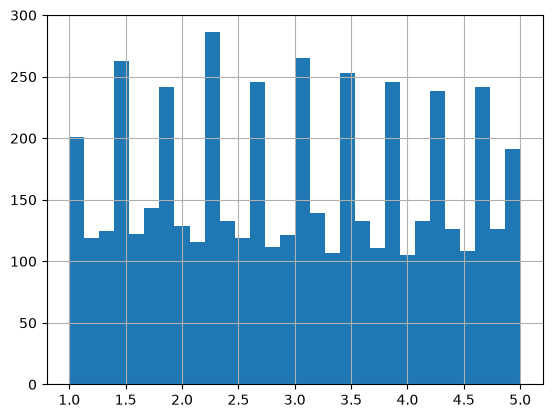

In [48]:
df['customer_rating'].hist(bins=30)

3.2.11 revenue

In [49]:
df['revenue'].describe()

count    5000.000000
mean     1021.955148
std       825.584219
min        11.210000
25%       354.527500
50%       796.650000
75%      1515.690000
max      4119.330000
Name: revenue, dtype: float64

<Axes: >

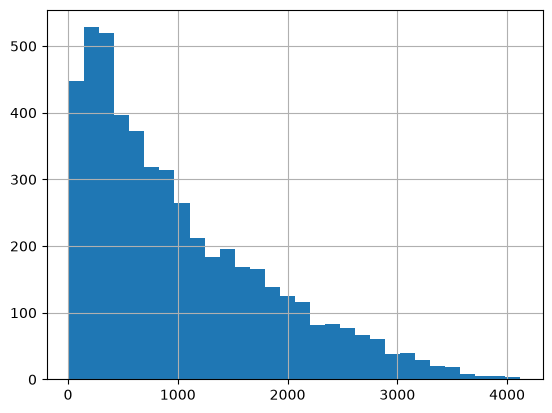

In [50]:
df["revenue"].hist(bins=30)

In [52]:
df['revenue'].skew()

np.float64(1.0017064603000962)

The distribution of revenues is right-skewed. The higher the revenue per order is, the fewer numbers of orders there are. The average amount of order revenue is 1021 while the median number is 797.  

In [53]:
df.to_pickle("df.pkl")